In [13]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci
import numpy as np

In [14]:
eug = pd.read_csv("cleaned_eug.csv")                        # | Read in new, cleaned data |
spd = pd.read_csv("cleaned_spd.csv")                        # | Read in new, cleaned data |

#### Difference in Differences plot

In [15]:
eug['calltime'] = pd.to_datetime(eug['calltime'])           # | Convert calltime into datetime again |
spd['calltime'] = pd.to_datetime(spd['calltime'])           # | Convert calltime into datetime again |

In [16]:
treatment_date = pd.to_datetime('2025-04-07')  # | Date when CAHOOTS was de-funded |

eug_counts = eug.groupby(eug['calltime'].dt.floor('D')).size().rolling(7).mean().reset_index().rename(columns = {0: "count"})       # | Get total number of call by week |                   
spd_counts = spd.groupby(spd['calltime'].dt.floor('D')).size().rolling(7).mean().reset_index().rename(columns = {0: "count"})       # | Get total number of call by week |  
merged = pd.merge(eug_counts, spd_counts, on='calltime').rename(columns={"count_x":"count_eug", "count_y":"count_spd"})             # | Merge these datasets together for easy plotting |

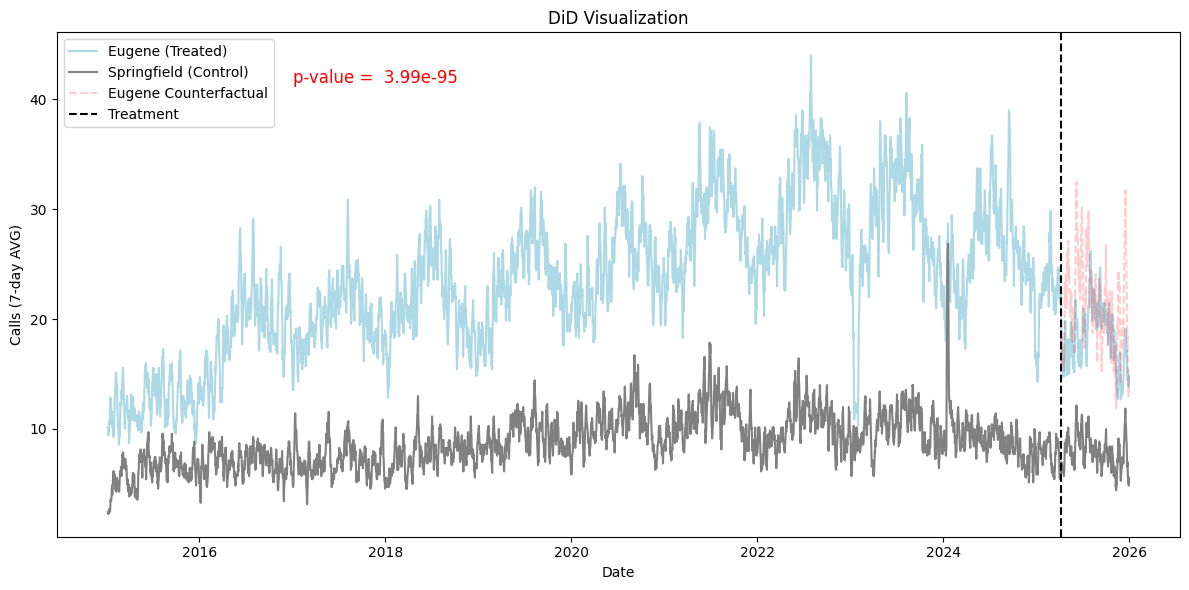

In [33]:

pre_date = merged['calltime'] < treatment_date
post_date = merged['calltime'] >= treatment_date

pre_ratio = (merged.loc[pre_date, 'count_eug'].mean() / 
             merged.loc[pre_date, 'count_spd'].mean())

# Counterfactual: Springfield's post-treatment values scaled by pre-treatment ratio
counterfactual_post = merged.loc[post_date, 'count_spd'] * pre_ratio

plt.figure(figsize=(12,6))
plt.plot(merged['calltime'], merged['count_eug'], label='Eugene (Treated)', color='lightblue');
plt.plot(merged['calltime'], merged['count_spd'], label='Springfield (Control)', color='gray');
plt.plot(merged.loc[post_date, 'calltime'], counterfactual_post, '--', color='red', label='Eugene Counterfactual', alpha=0.2)

plt.axvline(treatment_date, linestyle='--', color='black', label='Treatment')
plt.legend()
plt.title('DiD Visualization')
plt.ylabel('Calls (7-day AVG)')
plt.xlabel('Date')
plt.text(pd.to_datetime('2017-01-01'), 41.5, f'p-value =  3.99e-95', fontsize=12, color='red')
plt.tight_layout()
plt.savefig("diff_in_diff.png", dpi=300)
plt.show()

actual_post = merged.loc[post_date, 'count_eug'].mean()
counterfactual_mean = counterfactual_post.mean()
did_estimate = actual_post - counterfactual_mean


#### Conduct T-Test

In [18]:
before_treatment = merged[merged["calltime"] < treatment_date]["count_eug"]
after_treatment = merged[merged["calltime"] > treatment_date]["count_eug"]

# Perform test
t_val, p = sci.ttest_ind(before_treatment, after_treatment, equal_var=False, nan_policy='omit')               # | Independent Two-Sample T-Test since sizes of before + after not same |
                                                                                                              # | equal_var=False since variances are NOT the same                     |
print(f"P-value: {p}")                                                                                        # | nan_policy="omit" since some observations are missing/nan            |


P-value: 3.9940943925041096e-95


In [19]:
if p < 0.05:
    print("We reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.")
else: 
    print("We fail to reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.") 


We reject the null hypothesis that the mean of the number of welfare check calls is the same after treatment.


#### Meaning behind plot

From the difference in differences plot above, we see that the volume of welfare check calls is always greater than the volume of welfare check calls in Springfield. This is expected, as Springfield is a smaller city than Eugene, and usually doesn't require as many welfare check calls. 

Both cities follow a pattern of seasonal ups and downs in terms of welfare check calls, where sometimes they both drop and sometimes rise. However, after the treatment was given to Eugene (CAHOOTS was defunded) on April 7 of 2025, we see that afterwards there is a slight drop in the weekly volume of welfare check calls while Springfield's volume remained relatively the same. 

This may show that as a result of CAHOOTS being defunded, that we see a general decline in the number of welfare check calls in Eugene. Though a small difference, a drop in the weekly volume of welfare check calls is significant when aiming to keep everyone in the city in good health and in good security. 

#### Meaning behind t-test

The reason this t-test was conducted was to see if there was a statistically significant change in the average weekly volume before and after CAHOOTS was defunded. That is, was the drop in welfare check calls really that significant? 

The null hypothesis ($H_0$) was that the mean of the number of welfare check calls is the same after the treatment and the alternative hypothesis ($H_1%) is that there was a significant difference in the average volume of welfare check calls. 

After conducting a t-test at the 5% significance level, the resulting p-value was 3.99e-95, which is essentially 0. Since 0 < 0.05, we reject $H_1$ and instead find that there was a significant difference in the weekly volume of welfare check calls (we go with $H_!$).